<a href="https://colab.research.google.com/github/masondelan/ads504-bitcoin-project/blob/main/ADS_504_Group_5_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADS 504 Group 5. Predicting Bitcoin Price Direction
## Notebook 1. Exploratory Data Analysis and Preprocessing

**Team:** Mehson Mason Delan, Nikita Rogers, Dana Neuman
**University of San Diego, M.S. Applied Data Science**

This notebook is the exploratory analysis and preprocessing step for our project. The project goal is to predict whether Bitcoin's price goes up or down in the next hour. Instead of predicting the exact price we predict the direction, up (1) or down (0), so this is a binary classification problem that uses only market data available up to and including the current hour.

The rubric for this step asks us to work through five things, and we answer each one as we go:

1. How did we make sure we are ready to apply machine learning models? (Sections 2 and 4)
2. How will we pick the best model? (Section 10)
3. How do we define and refine the feature variables we may use for modeling? (Sections 7 and 8)
4. How do we handle missing values or human error? (Section 2)
5. How do we identify outliers? (Section 5)

We wrap up with a short summary at the end.

### About the data

We use hourly BTCUSDT candlesticks from Binance public market data covering January 2021 through December 2024. Hourly candles matter here for two reasons. First, the course asks for at least 10,000 rows, and daily candles over the same span would only give us about 1,460, while four years of hourly candles gives us roughly 35,000. Second, this window covers very different market conditions, the 2021 bull run, the 2022 bear market that pushed price below 20,000 dollars, and the recovery through 2024 that took it back above 100,000. That range of conditions is useful for judging whether a model generalizes instead of just memorizing one regime.

## 0. Environment and imports

Everything below is preinstalled on Google Colab, so there is no pip install step in this notebook. The heavier libraries we use for the actual model training (xgboost and lightgbm) live in the modeling notebook, not here.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import io, os, zipfile
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from IPython.display import display

SEED = 42
np.random.seed(SEED)

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 12

os.makedirs("data/raw", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)
print("environment ready")

environment ready


## 1. Load and assemble the data

Binance serves one zip file per month at a fixed URL pattern. We download the 48 monthly files from January 2021 to December 2024, unzip each one, and stack them into a single table. The raw files have no header row, so we name the 12 columns by hand from the Binance documentation. We wrap each download in a try and except so that if a single month is ever unavailable the loop keeps going instead of failing, and we print how many months we actually got.

In [2]:
BASE = "https://data.binance.vision/data/spot/monthly/klines/BTCUSDT/1h"
COLS = ["open_time", "open", "high", "low", "close", "volume", "close_time",
        "quote_asset_volume", "num_trades", "taker_buy_base_volume",
        "taker_buy_quote_volume", "ignore"]

def month_list(y0, m0, y1, m1):
    out, y, m = [], y0, m0
    while (y, m) <= (y1, m1):
        out.append((y, m))
        m += 1
        if m == 13:
            m, y = 1, y + 1
    return out

frames, missed = [], []
for y, m in month_list(2021, 1, 2024, 12):
    url = f"{BASE}/BTCUSDT-1h-{y}-{m:02d}.zip"
    try:
        content = requests.get(url, timeout=60).content
        with zipfile.ZipFile(io.BytesIO(content)) as zf:
            with zf.open(zf.namelist()[0]) as fh:
                frames.append(pd.read_csv(fh, header=None, names=COLS))
    except Exception as e:
        missed.append((y, m))

# some newer monthly files ship a header row, so coerce to numeric and drop any bad rows
raw = pd.concat(frames, ignore_index=True)
for c in COLS:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw = raw.dropna(subset=["open_time"]).reset_index(drop=True)

print(f"downloaded {len(frames)} months, missed {len(missed)}")
print(f"assembled shape: {raw.shape}")

downloaded 48 months, missed 0
assembled shape: (35050, 12)


In [3]:
# parse the millisecond epoch open_time into a real datetime, sort, and use it as the index
raw["datetime"] = pd.to_datetime(raw["open_time"], unit="ms")
raw = raw.sort_values("datetime").reset_index(drop=True)

# keep the columns we actually use, drop the always-empty "ignore" column
df = raw.set_index("datetime")[["open", "high", "low", "close", "volume",
                                "num_trades", "quote_asset_volume", "taker_buy_base_volume"]].copy()
df.head()

,open,high,low,close,volume,num_trades,quote_asset_volume,taker_buy_base_volume
datetime,,,,,,,,
2021-01-01 00:00:00,28923.63,29031.34,28690.17,28995.13,2311.811445,58389,6.676883e+07,1215.359238
2021-01-01 01:00:00,28995.13,29470.00,28960.35,29409.99,5403.068471,103896,1.583578e+08,3160.041701
2021-01-01 02:00:00,29410.00,29465.26,29120.03,29194.65,2384.231560,57646,6.984265e+07,1203.433506
2021-01-01 03:00:00,29195.25,29367.00,29150.02,29278.40,1461.345077,42510,4.276078e+07,775.915666
2021-01-01 04:00:00,29278.41,29395.00,29029.40,29220.31,2038.046803,55414,5.961464e+07,1003.342834


In [4]:
glance = pd.DataFrame({
    "value": [f"{len(df):,}", df.shape[1],
              str(df.index.min()), str(df.index.max()),
              f"{(df.index.max() - df.index.min()).days} days",
              "1 hour"]
}, index=["rows", "columns kept", "first candle", "last candle", "span", "candle size"])
print("Table 1. Dataset at a glance")
display(glance)

Table 1. Dataset at a glance


,value
rows,"35,050"
columns kept,8
first candle,2021-01-01 00:00:00
last candle,2024-12-31 23:00:00
span,1460 days
candle size,1 hour


We end up with about 35,000 rows, which clears the 10,000 row minimum with a lot of room to spare, and each row is one hour of trading.

## 2. Are we ready to apply machine learning models? Data quality checks

Being "ready" for modeling is not only about having enough rows. Before we trust any model we check that the data is clean and correctly shaped. For time series market data we look at four things.

1. **Types.** Every price and volume column should be numeric. If something loaded as text it would quietly break the math later.
2. **Missing values.** A gap in the price columns would bias any rolling calculation built on top of it.
3. **A complete, ordered time index.** Our features assume evenly spaced one hour steps, so duplicate timestamps or missing hours matter.
4. **Impossible values (human or feed error).** In candlestick data a few things are impossible by definition. The high cannot be below the low, the high cannot be below the open or the close, the low cannot be above the open or the close, and prices and volume cannot be negative. Any of these would point to a bad row.

In [5]:
print("Table 2. Column types")
display(df.dtypes.to_frame("dtype"))

Table 2. Column types


,dtype
open,float64
high,float64
low,float64
close,float64
volume,float64
num_trades,int64
quote_asset_volume,float64
taker_buy_base_volume,float64


In [6]:
miss = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3)
})
print("Table 3. Missing values by column")
display(miss)
print("duplicate timestamps:", int(df.index.duplicated().sum()))

Table 3. Missing values by column


,missing,missing_pct
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
volume,0,0.0
num_trades,0,0.0
quote_asset_volume,0,0.0
taker_buy_base_volume,0,0.0


duplicate timestamps: 0


In [7]:
# how evenly spaced is the time index? the gap between candles should always be one hour
gaps = df.index.to_series().diff().dropna()
one_hour = pd.Timedelta(hours=1)
missing_candles = int(((gaps - one_hour) / one_hour).clip(lower=0).sum())

gap_tbl = gaps.value_counts().sort_index().head(6).rename_axis("gap").to_frame("count")
print("Table 4. Spacing between consecutive candles")
display(gap_tbl)
print(f"gaps longer than 1 hour: {(gaps > one_hour).sum()}")
print(f"total missing candles implied by those gaps: {missing_candles}")

Table 4. Spacing between consecutive candles


,count
gap,
0 days 01:00:00,35042
0 days 02:00:00,3
0 days 03:00:00,2
0 days 04:00:00,1
0 days 05:00:00,1


gaps longer than 1 hour: 7
total missing candles implied by those gaps: 14


In [8]:
# integrity checks: count rows that violate a rule that should never be broken
checks = {
    "high < low":                int((df["high"] < df["low"]).sum()),
    "high < open or high < close": int(((df["high"] < df["open"]) | (df["high"] < df["close"])).sum()),
    "low > open or low > close":   int(((df["low"] > df["open"]) | (df["low"] > df["close"])).sum()),
    "non-positive price":        int((df[["open","high","low","close"]] <= 0).any(axis=1).sum()),
    "negative volume":           int((df["volume"] < 0).sum()),
    "zero-volume candles":       int((df["volume"] == 0).sum()),
}
print("Table 5. Integrity / human-error checks (count of bad rows)")
display(pd.Series(checks, name="rows").to_frame())

Table 5. Integrity / human-error checks (count of bad rows)


,rows
high < low,0
high < open or high < close,0
low > open or low > close,0
non-positive price,0
negative volume,0
zero-volume candles,2


### What we found, and how we handle missing values and errors

The data loads clean. Every column is numeric, there are no missing values in any of the roughly 35,000 rows, and there are no duplicate timestamps. Every check for an impossible value comes back zero, so there is no row where the high sits below the low, no negative price, and no negative volume. That is what we expect from an exchange feed rather than hand entered data, so there is very little room for the kind of human error we would worry about in a survey or a spreadsheet. The two zero-volume candles in the table are real hours where no trades cleared, not errors, so we leave them.

The one thing worth noting is a small number of missing hours. The spacing between candles is almost always exactly one hour, but a handful of gaps are longer, and together they add up to only 14 missing candles across four years. These line up with short Binance maintenance windows. We leave them as they are instead of filling them, because inventing prices for hours the exchange did not trade would introduce a worse error than a few gaps in 35,000 rows, and the gaps are far too rare to affect the hourly patterns we model.

To be explicit about the plan the rubric asks for, if we had found missing values we would handle them by type. For a short gap in a price column, a forward fill is reasonable because the last traded price is the best estimate of the next one in a market. For a fully missing candle we would drop the row rather than guess a whole bar. For the target and for the engineered features, some values are undefined at the very start by construction, for example a 24 hour rolling average has no value in the first 24 hours, and we drop those warmup rows rather than impute them.

## 3. The target variable

Our label is the direction of the next hour. For each row we look one hour ahead and set the target to 1 if the next close is higher than the current close, and 0 otherwise. Because the label looks into the future, the very last row has no answer and we drop it.

This is also where we have to be careful about leakage, which is the biggest risk in a time series project. The target is a future move, so every feature we build later must use only information available at or before the current hour, and we must never shuffle the rows when we split. We come back to both points in Sections 7 and 9.

Table 6. Target class balance


,count,share
down (0),17289,0.4933
up (1),17760,0.5067


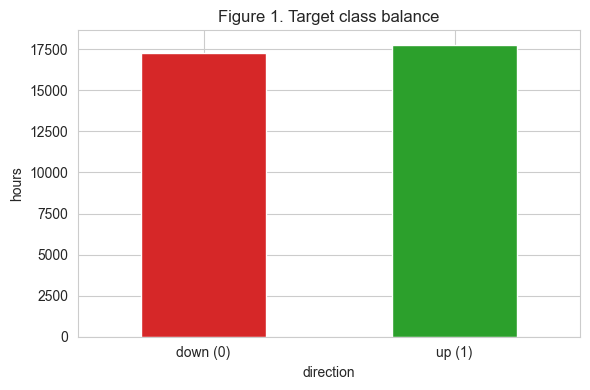

In [9]:
df["next_close"] = df["close"].shift(-1)
df["direction"] = (df["next_close"] > df["close"]).astype(int)
df = df.iloc[:-1].copy()   # drop the last row, which has no next hour

counts = df["direction"].value_counts().sort_index()
share = df["direction"].value_counts(normalize=True).sort_index()
bal = pd.DataFrame({"count": counts, "share": share.round(4)})
bal.index = ["down (0)", "up (1)"]
print("Table 6. Target class balance")
display(bal)

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#d62728", "#2ca02c"])
ax.set_xticklabels(["down (0)", "up (1)"], rotation=0)
ax.set_title("Figure 1. Target class balance")
ax.set_ylabel("hours")
plt.tight_layout(); plt.savefig("reports/figures/01_target_balance.png", dpi=100); plt.show()

The classes are close to balanced, about 50.7 percent up and 49.3 percent down. That is good news for a classifier because we do not have to fight a heavy class imbalance, but it also sets a hard baseline. A model that always guesses "up" would already be right about 50.7 percent of the time, so anything we build has to beat that number to be worth anything. We use that fact when we choose our evaluation metric in Section 10.

## 4. Distributions and stationarity

Next we look at how the prices and returns are distributed. This is the second half of the "are we ready" question, because the shape of the data decides what we should feed a model. Raw price is not something a classifier can use directly, so we study the returns instead.

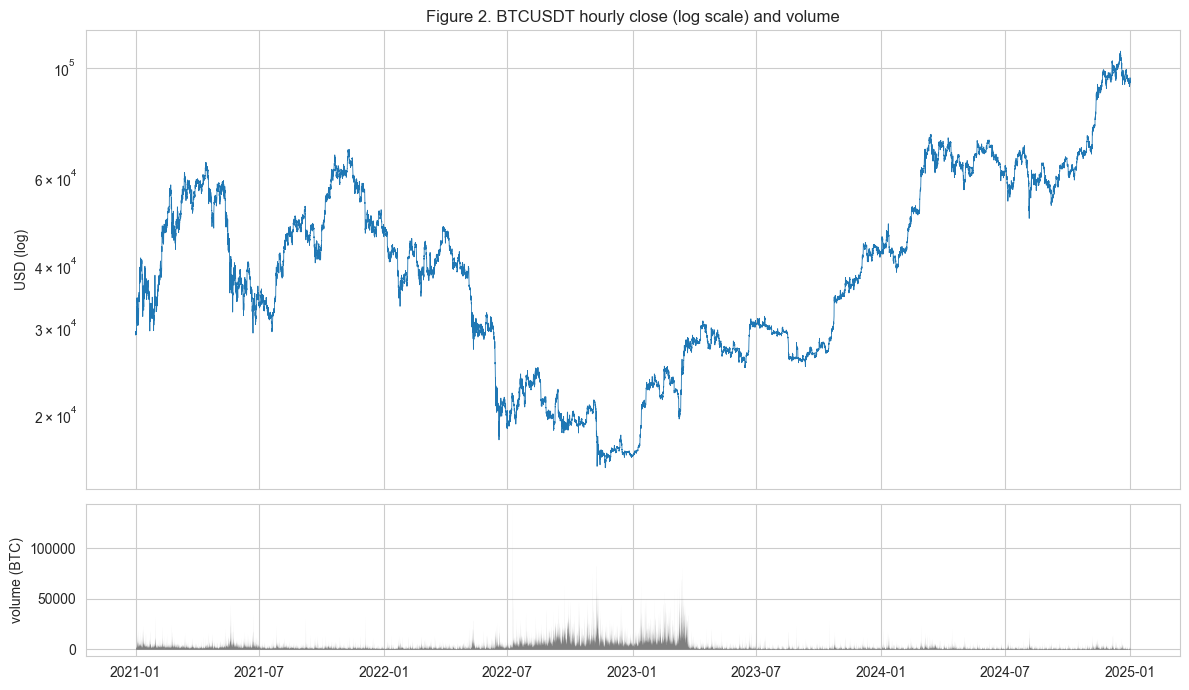

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(df.index, df["close"], lw=0.6, color="#1f77b4")
ax[0].set_yscale("log")
ax[0].set_title("Figure 2. BTCUSDT hourly close (log scale) and volume")
ax[0].set_ylabel("USD (log)")
ax[1].fill_between(df.index, df["volume"], color="#7f7f7f", lw=0)
ax[1].set_ylabel("volume (BTC)")
plt.tight_layout(); plt.savefig("reports/figures/02_price_volume.png", dpi=100); plt.show()

In [11]:
print("Table 7. Summary statistics for price and volume")
display(df[["open","high","low","close","volume","num_trades"]].describe().round(2))

Table 7. Summary statistics for price and volume


,open,high,low,close,volume,num_trades
count,35049.00,35049.00,35049.00,35049.00,35049.00,35049.00
mean,42583.31,42773.56,42383.70,42585.15,3666.51,109077.02
std,18799.65,18874.92,18719.65,18801.48,5107.82,117123.40
min,15648.23,15769.99,15476.00,15649.52,0.00,0.00
25%,27261.06,27357.33,27180.17,27261.07,986.22,38335.00
50%,39732.84,39935.10,39524.12,39732.92,1867.02,65927.00
75%,57338.58,57616.34,57024.01,57339.19,4151.26,133718.00
max,108258.38,108353.00,107130.00,108258.39,137207.19,1442097.00


In [12]:
# work in log returns, which is the standard way to measure period-over-period change
df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
r = df["log_ret"].dropna()

ret_stats = pd.Series({
    "mean":            r.mean(),
    "std":             r.std(),
    "skewness":        stats.skew(r),
    "excess kurtosis": stats.kurtosis(r),
    "min":             r.min(),
    "max":             r.max(),
    "annualized vol":  r.std() * np.sqrt(24 * 365),
}, name="hourly log return")
print("Table 8. Hourly log-return statistics")
display(ret_stats.to_frame().round(6))

# stationarity: a formal check of whether the series has a stable mean over time
adf_close = adfuller(df["close"].dropna(), autolag="AIC")
adf_ret   = adfuller(r, autolag="AIC")
adf_tbl = pd.DataFrame({
    "ADF statistic": [adf_close[0], adf_ret[0]],
    "p-value":       [adf_close[1], adf_ret[1]],
    "stationary at 5%": [adf_close[1] < 0.05, adf_ret[1] < 0.05],
}, index=["close price", "log return"]).round(4)
print("Table 9. Augmented Dickey-Fuller stationarity test")
display(adf_tbl)

Table 8. Hourly log-return statistics


,hourly log return
mean,0.000033
std,0.006769
skewness,-0.197649
excess kurtosis,15.347399
min,-0.093810
max,0.116145
annualized vol,0.633560


Table 9. Augmented Dickey-Fuller stationarity test


,ADF statistic,p-value,stationary at 5%
close price,-0.1911,0.9396,False
log return,-26.3673,0.0000,True


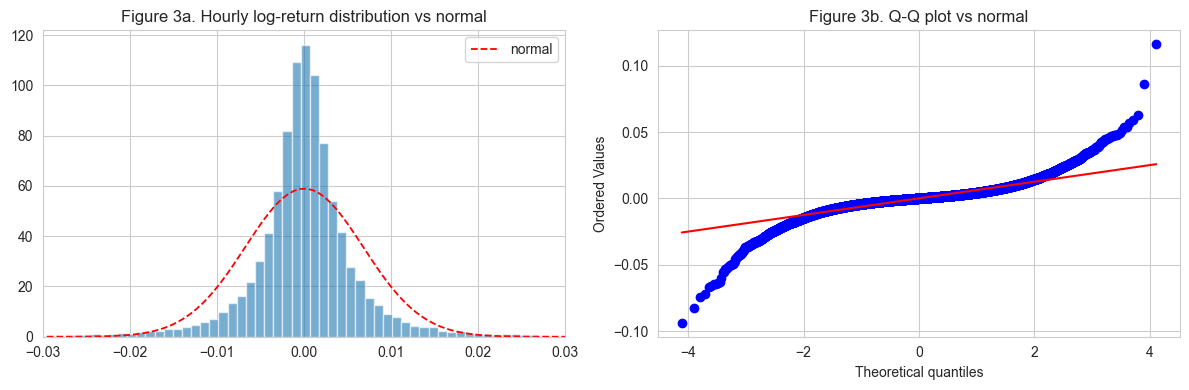

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(r, bins=200, density=True, alpha=0.6, color="#1f77b4")
xs = np.linspace(r.min(), r.max(), 300)
ax[0].plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), "r--", lw=1.3, label="normal")
ax[0].set_xlim(-0.03, 0.03); ax[0].legend()
ax[0].set_title("Figure 3a. Hourly log-return distribution vs normal")
stats.probplot(r, dist="norm", plot=ax[1])
ax[1].set_title("Figure 3b. Q-Q plot vs normal")
plt.tight_layout(); plt.savefig("reports/figures/03_returns.png", dpi=100); plt.show()

Two things here shape how we model.

First, the price itself is not stationary. The Dickey-Fuller test on the close gives a p-value near 0.94, so we cannot reject the idea that its average drifts over time, which is obvious from the chart since price ranges from about 15,600 to 108,000 dollars. The log returns, on the other hand, have a p-value near zero, so they are stationary and swing around a mean of essentially zero. This is exactly why we do not feed raw price to the model. A dollar level from 2021 means nothing in 2024, but a one hour return is comparable across the whole span. All of our features are built from returns and ratios rather than from price levels.

Second, the returns have very fat tails. The excess kurtosis is about 15, far above the 0 you would see from a normal distribution, and the histogram and Q-Q plot both show it clearly, with a tall narrow peak and long tails on both sides. Most hours barely move, but a small number move violently. This matters for how we treat outliers in the next section and for how we scale features before a linear model.

## 5. Identifying outliers

In a lot of datasets an outlier is a mistake to remove. In market data most extreme values are real, they are the crashes and rallies, and those are exactly the moments we care about. So our goal is not to delete outliers but to find them, understand them, and decide how to keep them from distorting the model.

We flag outliers on the hourly return two ways. The IQR rule flags anything more than 1.5 times the interquartile range beyond the quartiles, which is the standard boxplot rule. The z-score rule flags anything more than a set number of standard deviations from the mean. We also list the single largest moves and check what they line up with.

In [14]:
q1, q3 = r.quantile(0.25), r.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
z = (r - r.mean()) / r.std()

out_tbl = pd.DataFrame({
    "method": ["IQR (1.5x)", "|z| > 3", "|z| > 4"],
    "threshold": [f"[{lo:.4f}, {hi:.4f}]", "3 sd", "4 sd"],
    "flagged": [int(((r < lo) | (r > hi)).sum()), int((z.abs() > 3).sum()), int((z.abs() > 4).sum())],
})
out_tbl["percent"] = (out_tbl["flagged"] / len(r) * 100).round(2)
print("Table 10. Outliers in the hourly return")
display(out_tbl)

big = r.reindex(r.abs().sort_values(ascending=False).index).head(6)
big_tbl = pd.DataFrame({"log return": big.values, "percent move": (big.values * 100).round(2)},
                       index=big.index.strftime("%Y-%m-%d %H:%M"))
print("Table 11. Six largest hourly moves")
display(big_tbl.round(4))

Table 10. Outliers in the hourly return


,method,threshold,flagged,percent
0,IQR (1.5x),"[-0.0100, 0.0102]",3215,9.17
1,|z| > 3,3 sd,705,2.01
2,|z| > 4,4 sd,292,0.83


Table 11. Six largest hourly moves


,log return,percent move
datetime,,
2021-01-29 08:00,0.1161,11.61
2021-05-19 12:00,-0.0938,-9.38
2021-02-08 12:00,0.0865,8.65
2021-05-21 14:00,-0.0830,-8.30
2021-01-02 20:00,-0.0741,-7.41
2022-05-11 12:00,-0.0725,-7.25


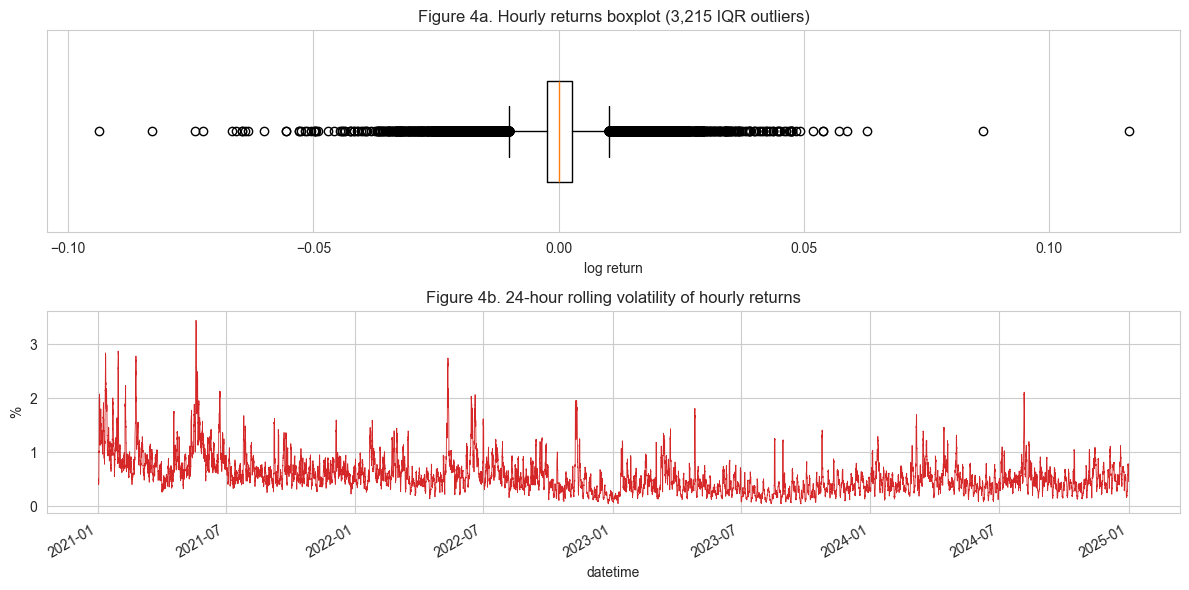

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].boxplot(r, vert=False, whis=1.5, widths=0.5)
ax[0].set_title(f"Figure 4a. Hourly returns boxplot ({int(((r<lo)|(r>hi)).sum()):,} IQR outliers)")
ax[0].set_xlabel("log return"); ax[0].set_yticks([])
(df["log_ret"].rolling(24).std() * 100).plot(ax=ax[1], lw=0.6, color="#d62728")
ax[1].set_title("Figure 4b. 24-hour rolling volatility of hourly returns")
ax[1].set_ylabel("%")
plt.tight_layout(); plt.savefig("reports/figures/04_outliers.png", dpi=100); plt.show()

The IQR rule flags about 9 percent of all hours as outliers, which sounds alarming until you remember the fat tails from the last section. When a distribution has kurtosis of 15, the boxplot rule that was designed for roughly normal data will always flag a large share of points, so IQR overcounts here. The z-score view is more useful. Only about 0.8 percent of hours are beyond four standard deviations, and those are the truly extreme moves. Five of the six largest fall in the first half of 2021, which was the most volatile stretch in the window, and they line up with well known events like the late January 2021 rally and the May 2021 crash. The sixth is the May 2022 crash. The rolling volatility chart tells the same story a different way. Volatility is not constant, it clusters into calm and stormy periods, which is a normal feature of financial data called volatility clustering.

Our decision is to keep every outlier, because they are real market behavior and deleting them would throw away exactly the large moves a direction model should learn from. What we do instead is protect the model from them. Tree based models like random forest and gradient boosting are not very sensitive to extreme values, because they split on rank order rather than the raw size of a number. For the linear model we standardize the features and can clip the most extreme values if needed, so a single 11 percent hour does not take over the fit. So we keep the outliers as real information instead of throwing them out.

## 6. Relationships and seasonality

Before building features we check how much predictable structure is even there. Two simple views tell us a lot.

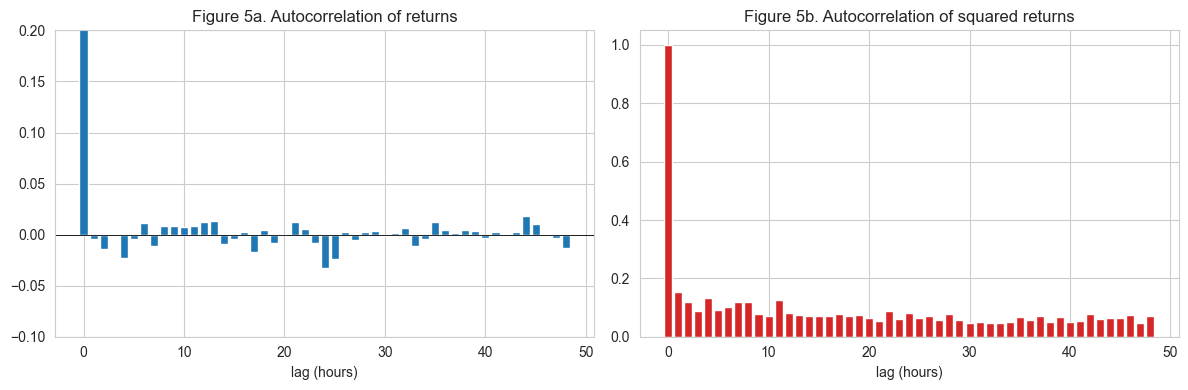

In [16]:
lags = 48
ac_r  = acf(r, nlags=lags)
ac_r2 = acf(r**2, nlags=lags)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(lags + 1), ac_r, color="#1f77b4"); ax[0].set_ylim(-0.1, 0.2)
ax[0].set_title("Figure 5a. Autocorrelation of returns")
ax[1].bar(range(lags + 1), ac_r2, color="#d62728")
ax[1].set_title("Figure 5b. Autocorrelation of squared returns")
for a in ax:
    a.axhline(0, color="k", lw=0.6); a.set_xlabel("lag (hours)")
plt.tight_layout(); plt.savefig("reports/figures/05_acf.png", dpi=100); plt.show()

Table 12. Seasonality in the up-rate


,value
best hour up% (UTC),20:00 = 54.3%
worst hour up% (UTC),15:00 = 47.8%
best day,Wed = 51.2%
worst day,Thu = 49.4%


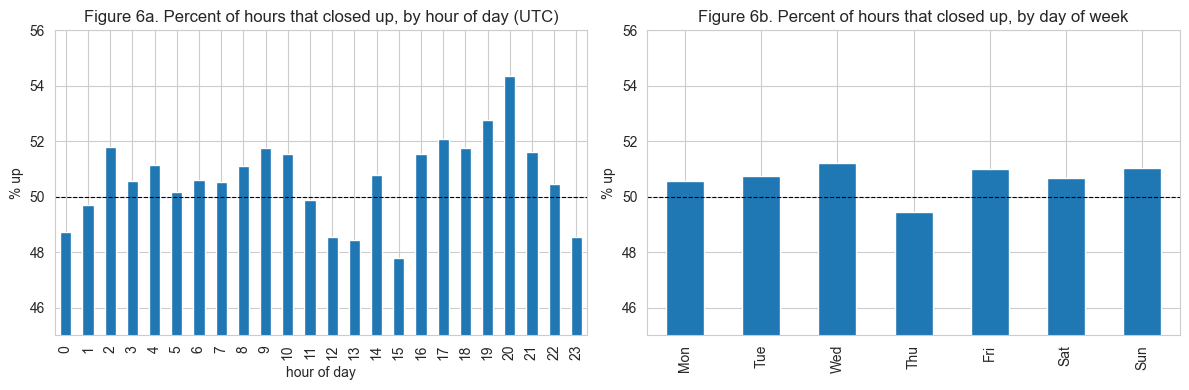

In [17]:
by_hour = df.groupby(df.index.hour)["direction"].mean() * 100
by_dow  = df.groupby(df.index.dayofweek)["direction"].mean() * 100
by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
season = pd.DataFrame({
    "best hour up% (UTC)":  [f"{by_hour.idxmax()}:00 = {by_hour.max():.1f}%"],
    "worst hour up% (UTC)": [f"{by_hour.idxmin()}:00 = {by_hour.min():.1f}%"],
    "best day":  [f"{by_dow.idxmax()} = {by_dow.max():.1f}%"],
    "worst day": [f"{by_dow.idxmin()} = {by_dow.min():.1f}%"],
}).T.rename(columns={0: "value"})
print("Table 12. Seasonality in the up-rate")
display(season)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
by_hour.plot(kind="bar", ax=ax[0], color="#1f77b4")
ax[0].axhline(50, color="k", ls="--", lw=0.8); ax[0].set_ylim(45, 56)
ax[0].set_title("Figure 6a. Percent of hours that closed up, by hour of day (UTC)")
ax[0].set_xlabel("hour of day"); ax[0].set_ylabel("% up")
by_dow.plot(kind="bar", ax=ax[1], color="#1f77b4")
ax[1].axhline(50, color="k", ls="--", lw=0.8); ax[1].set_ylim(45, 56)
ax[1].set_title("Figure 6b. Percent of hours that closed up, by day of week")
ax[1].set_xlabel(""); ax[1].set_ylabel("% up")
plt.tight_layout(); plt.savefig("reports/figures/06_seasonality.png", dpi=100); plt.show()

The autocorrelation of returns is basically zero at every lag past the first, which is a sign that this is a hard problem. The next hour's return is close to unpredictable from past returns alone, which is what you tend to see in a market that is hard to time hour to hour. The autocorrelation of squared returns looks different, it stays clearly positive for many lags, which confirms the volatility clustering we saw earlier. That is why we build volatility features, since the size of the moves is much more predictable than their direction.

The seasonality view (Figure 6) shows a mild but real pattern. The up-rate by hour ranges from about 48 to 54 percent depending on the hour of day in UTC, and the day of week effect is weaker, roughly 49 to 51 percent. It is small, but it is free information, so we include the hour and the day of week as features and let the model decide if they help.

## 7. Defining the candidate feature variables

Now we turn the raw candles into features. The main rule, from the leakage warning in Section 3, is that a feature at hour t may only use information from hour t and earlier, because the target is the move from t to t+1. Anything that peeks at the future would make our results look good now but fail on real future data. Every rolling window and every lag below is backward looking for that reason.

We group the candidate features into five families that match the README plan.

- **Returns and lags.** The current log return and its values 1, 2, 3, 6, 12, and 24 hours ago. These capture short term momentum and mean reversion.
- **Trend.** How far price sits above or below its 10 and 20 hour moving averages, expressed as a ratio so it stays comparable across price levels, plus MACD, which is the gap between a fast and a slow exponential average.
- **Momentum.** RSI over 14 hours, a bounded 0 to 100 measure of how one sided recent moves have been.
- **Volatility.** Rolling standard deviation of returns over 6 and 24 hours, and the Bollinger band width and position, which measure how stretched price is relative to its recent range.
- **Volume and candle shape.** Volume and trade count relative to their own 24 hour average, the high to low range as a fraction of price, and the candle body, plus the calendar features hour and day of week.

In [18]:
c, h, l, o, v = df["close"], df["high"], df["low"], df["open"], df["volume"]
feat = pd.DataFrame(index=df.index)

# returns and lags
feat["log_ret"] = df["log_ret"]
for k in (1, 2, 3, 6, 12, 24):
    feat[f"ret_lag{k}"] = df["log_ret"].shift(k)

# volatility from returns
feat["roll_mean_6"] = df["log_ret"].rolling(6).mean()
feat["roll_std_6"]  = df["log_ret"].rolling(6).std()
feat["roll_std_24"] = df["log_ret"].rolling(24).std()

# trend: distance from moving averages (scale free) and MACD
feat["sma10_ratio"] = c / c.rolling(10).mean() - 1
feat["sma20_ratio"] = c / c.rolling(20).mean() - 1
ema12 = c.ewm(span=12, adjust=False).mean()
ema26 = c.ewm(span=26, adjust=False).mean()
macd  = ema12 - ema26
signal = macd.ewm(span=9, adjust=False).mean()
feat["macd"]      = macd / c
feat["macd_hist"] = (macd - signal) / c

# momentum: RSI(14) with Wilder smoothing
delta = c.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/14, adjust=False, min_periods=14).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False, min_periods=14).mean()
feat["rsi14"] = 100 - 100 / (1 + avg_gain / avg_loss)

# volatility bands: Bollinger(20, 2)
mid = c.rolling(20).mean()
sd  = c.rolling(20).std()
feat["bb_width"] = (4 * sd) / mid
feat["bb_pctb"]  = (c - (mid - 2 * sd)) / ((mid + 2 * sd) - (mid - 2 * sd))

# volume and candle shape
feat["range_pct"]    = (h - l) / c
feat["body_pct"]     = (c - o) / o
feat["vol_ratio"]    = v / v.rolling(24).mean()
feat["trades_ratio"] = df["num_trades"] / df["num_trades"].rolling(24).mean()

# calendar
feat["hour"] = df.index.hour
feat["dow"]  = df.index.dayofweek

feat["direction"] = df["direction"]

before = len(feat)
feat = feat.dropna()   # drop the warmup rows where a rolling window is not yet defined
feature_cols = [x for x in feat.columns if x != "direction"]
print(f"{len(feature_cols)} candidate features, {len(feat):,} usable rows "
      f"(dropped {before - len(feat)} warmup rows)")
feat.head()

23 candidate features, 35,024 usable rows (dropped 25 warmup rows)


,log_ret,ret_lag1,ret_lag2,ret_lag3,ret_lag6,ret_lag12,ret_lag24,roll_mean_6,roll_std_6,roll_std_24,...,rsi14,bb_width,bb_pctb,range_pct,body_pct,vol_ratio,trades_ratio,hour,dow,direction
datetime,,,,,,,,,,,,,,,,,,,,,
2021-01-02 01:00:00,0.005533,-0.004586,0.002368,0.003489,-0.001503,0.007881,0.014207,0.001886,0.004120,0.004365,...,74.370511,0.016301,0.812254,0.010218,0.005533,0.890383,0.789465,1,5,0
2021-01-02 02:00:00,-0.001215,0.005533,-0.004586,0.002368,0.005905,-0.004659,-0.007349,0.000700,0.003739,0.004091,...,73.122176,0.016606,0.717553,0.005081,-0.001214,0.813134,0.681511,2,5,1
2021-01-02 03:00:00,0.000959,-0.001215,0.005533,-0.004586,-0.001390,-0.004757,0.002865,0.001091,0.003597,0.004055,...,73.500156,0.016563,0.749370,0.004280,0.000959,0.555688,0.656586,3,5,0
2021-01-02 04:00:00,-0.000079,0.000959,-0.001215,0.005533,0.003489,0.003826,-0.001986,0.000497,0.003411,0.004031,...,73.408466,0.015138,0.727955,0.005997,-0.000079,0.484601,0.731998,4,5,1
2021-01-02 05:00:00,0.008156,-0.000079,0.000959,-0.001215,0.002368,-0.007569,-0.001140,0.001461,0.004642,0.004333,...,76.657415,0.018272,1.101942,0.008123,0.008190,1.326563,0.959124,5,5,1


## 8. Refining the feature variables

Having 23 candidate features does not mean we should keep all 23. We refine the set with three checks.

1. **Signal against the target.** How strongly does each feature line up with the up or down label on its own.
2. **Redundancy.** Are two features basically measuring the same thing, which adds noise and hurts a linear model without adding any new information.
3. **Information content.** A ranking that can pick up nonlinear relationships that a plain correlation misses.

For anything we learn from the data, like the ranking below, we use only the training part, not the whole series, so this step does not leak future information.

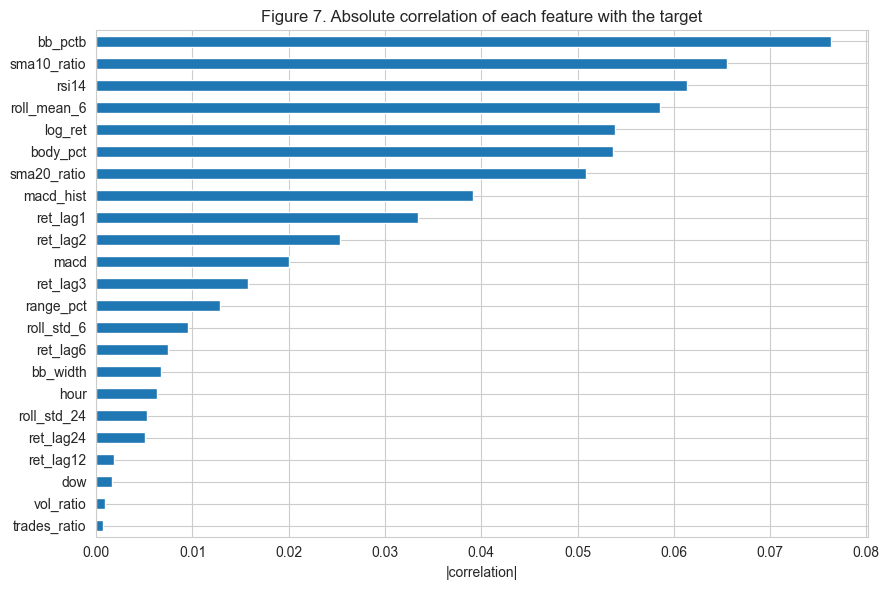

Table 13. Top features by absolute correlation with the target


,abs_corr
bb_pctb,0.0764
sma10_ratio,0.0656
rsi14,0.0614
roll_mean_6,0.0586
log_ret,0.0539
body_pct,0.0537
sma20_ratio,0.0509
macd_hist,0.0392


In [19]:
corr_t = feat[feature_cols].corrwith(feat["direction"]).abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
corr_t.iloc[::-1].plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Figure 7. Absolute correlation of each feature with the target")
ax.set_xlabel("|correlation|")
plt.tight_layout(); plt.savefig("reports/figures/07_corr_target.png", dpi=100); plt.show()
print("Table 13. Top features by absolute correlation with the target")
display(corr_t.head(8).to_frame("abs_corr").round(4))

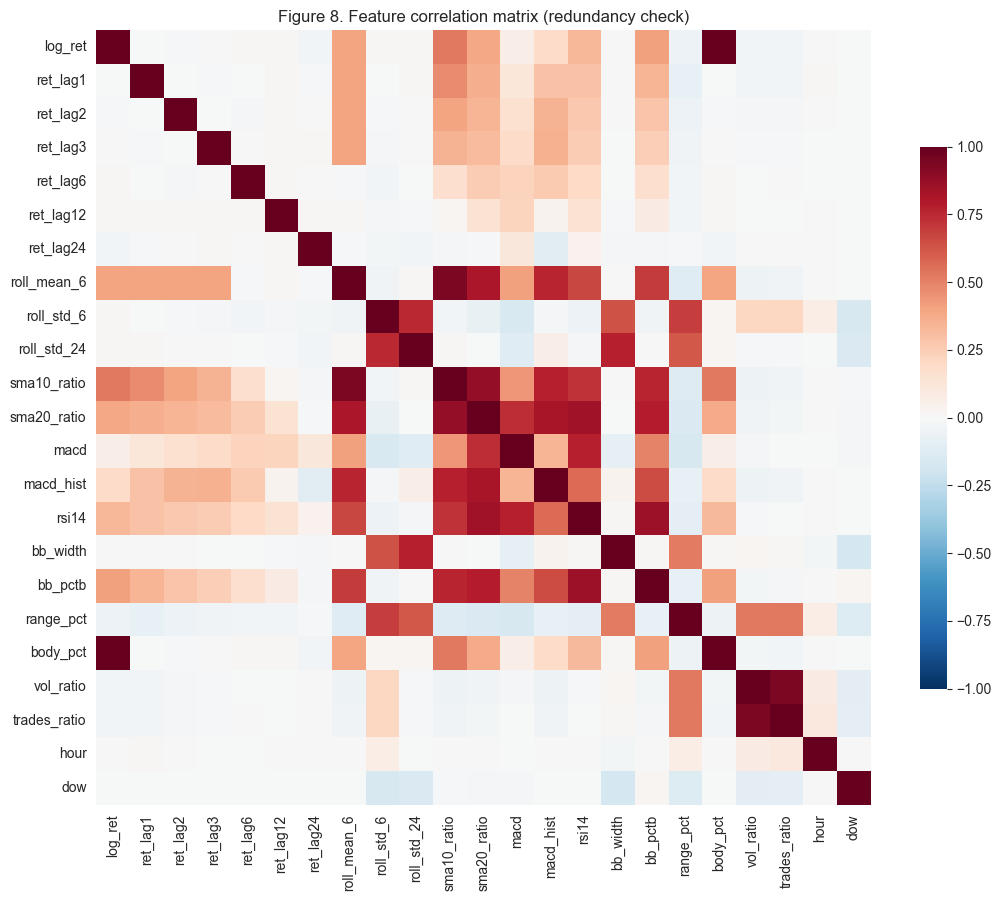

Table 14. Feature pairs with |correlation| > 0.9


,feature_a,feature_b,correlation
0,log_ret,body_pct,1.000
1,roll_mean_6,sma10_ratio,0.939
2,vol_ratio,trades_ratio,0.941


In [20]:
corr_mat = feat[feature_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_mat, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Figure 8. Feature correlation matrix (redundancy check)")
plt.tight_layout(); plt.savefig("reports/figures/08_corr_matrix.png", dpi=100); plt.show()

# list the strongly redundant pairs
abs_c = corr_mat.abs()
pairs = [(abs_c.columns[i], abs_c.columns[j], corr_mat.iloc[i, j])
         for i in range(len(abs_c)) for j in range(i + 1, len(abs_c))
         if abs_c.iloc[i, j] > 0.9]
print("Table 14. Feature pairs with |correlation| > 0.9")
display(pd.DataFrame(pairs, columns=["feature_a", "feature_b", "correlation"]).round(3))

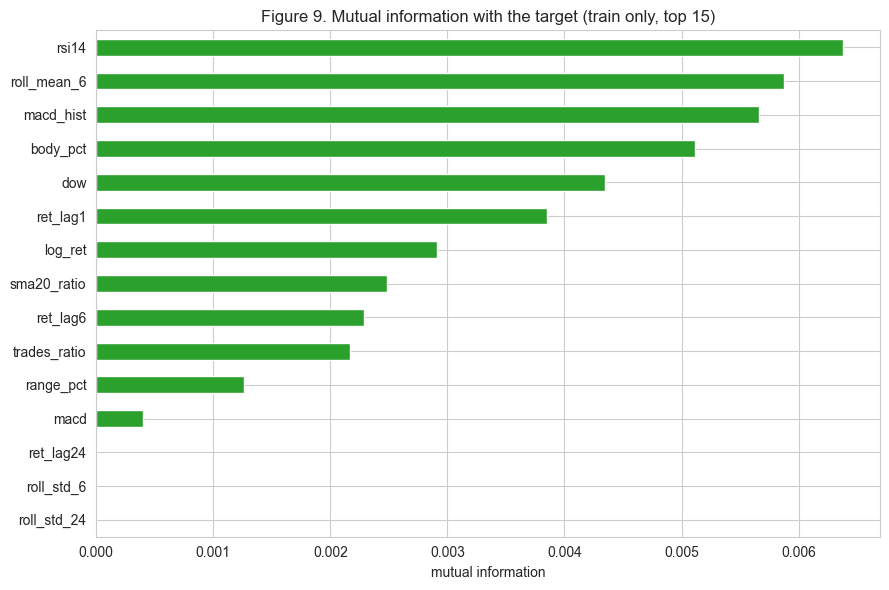

In [21]:
# time-ordered split so the ranking is learned only from the past (details in Section 9)
n = len(feat)
i_train = int(n * 0.70)
X_train = feat[feature_cols].iloc[:i_train]
y_train = feat["direction"].iloc[:i_train]

mi = mutual_info_classif(StandardScaler().fit_transform(X_train), y_train, random_state=SEED)
mi = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
mi.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#2ca02c")
ax.set_title("Figure 9. Mutual information with the target (train only, top 15)")
ax.set_xlabel("mutual information")
plt.tight_layout(); plt.savefig("reports/figures/09_mutual_info.png", dpi=100); plt.show()

Putting the three checks together, they point the same way. No single feature is strongly correlated with the next move on its own, the largest absolute correlation is only about 0.08, which again shows that hourly direction is hard. The features that do carry the most signal are the momentum and short trend group, Bollinger position, the distance from the 10 hour average, RSI, and the recent 6 hour average return, and the mutual information ranking agrees, with RSI, the 6 hour average return, and the MACD histogram near the top.

The redundancy check is where we actually trim. Three pairs are almost perfectly correlated. The candle body and the log return have a correlation of essentially 1, which makes sense because on a continuous exchange the open of each hour is the close of the previous hour, so the body of the candle is nearly the same number as the return. Volume ratio and trade count ratio move together at about 0.94, and the 6 hour average return overlaps heavily with the distance from the 10 hour average. From each of these pairs we drop one member, so we drop body_pct, trades_ratio, and roll_mean_6. That leaves a refined set of 20 features that keeps all the distinct information while removing the parts that would just add noise to a linear model. The tree models are less sensitive to this, but a single clean feature set that works for every model keeps the comparison in the next notebook fair.

In [22]:
drop_redundant = ["body_pct", "trades_ratio", "roll_mean_6"]
refined_cols = [c for c in feature_cols if c not in drop_redundant]
print(f"refined feature set: {len(refined_cols)} features")
print(refined_cols)

refined feature set: 20 features
['log_ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag6', 'ret_lag12', 'ret_lag24', 'roll_std_6', 'roll_std_24', 'sma10_ratio', 'sma20_ratio', 'macd', 'macd_hist', 'rsi14', 'bb_width', 'bb_pctb', 'range_pct', 'vol_ratio', 'hour', 'dow']


## 9. Train, validation, and test split, and scaling

This is the step where a time series project most often goes wrong, so we are careful here. We do not shuffle. Shuffling would let the model train on future hours and test on past ones, which leaks information and gives a score that would not hold up on real future data. Instead we split by time. The first 70 percent of the hours are training, the next 15 percent are validation for tuning, and the final 15 percent are a held out test set that stands in for the future. Because the split is by time, the test set is a genuinely later period than anything the model saw during training.

We also fit the scaler on the training data only, then apply it to validation and test. Fitting the scaler on the whole series would let the mean and standard deviation of the test period leak backward into training, which is a subtle but real form of leakage.

In [23]:
i_train = int(n * 0.70)
i_val   = int(n * 0.85)
train = feat.iloc[:i_train]
val   = feat.iloc[i_train:i_val]
test  = feat.iloc[i_val:]

split_tbl = pd.DataFrame({
    "rows":  [len(train), len(val), len(test)],
    "start": [train.index.min(), val.index.min(), test.index.min()],
    "end":   [train.index.max(), val.index.max(), test.index.max()],
    "up-rate": [train["direction"].mean().round(4),
                val["direction"].mean().round(4),
                test["direction"].mean().round(4)],
}, index=["train (70%)", "validation (15%)", "test (15%)"])
print("Table 15. Time-ordered split")
display(split_tbl)

# fit the scaler on training data only, then reuse it everywhere
scaler = StandardScaler().fit(train[refined_cols])
X_train_s = scaler.transform(train[refined_cols])
X_val_s   = scaler.transform(val[refined_cols])
X_test_s  = scaler.transform(test[refined_cols])
print("scaler fitted on train only; shapes:",
      X_train_s.shape, X_val_s.shape, X_test_s.shape)

Table 15. Time-ordered split


,rows,start,end,up-rate
train (70%),24516,2021-01-02 01:00:00,2023-10-21 02:00:00,0.5038
validation (15%),5254,2023-10-21 03:00:00,2024-05-27 00:00:00,0.5179
test (15%),5254,2024-05-27 01:00:00,2024-12-31 22:00:00,0.5097


scaler fitted on train only; shapes: (24516, 20) (5254, 20) (5254, 20)


## 10. How we will pick the best model

The full training and tuning happens in the modeling notebook, but the plan for choosing a model is part of preprocessing because it decides how we validate. Our approach has four parts.

**Baselines to beat.** Two of them. The majority class baseline always predicts up, which is right about half the time (50.4 percent on the training data in the table below), and the persistence baseline predicts that the next move repeats the last one. Any real model has to clear both.

**Candidate models.** A logistic regression as a simple linear baseline, then random forest, XGBoost, and LightGBM as stronger nonlinear models. We start simple and only move to the heavier boosted models if they clearly do better on the validation set.

**How we validate.** We use TimeSeriesSplit cross validation, which always trains on an earlier block and validates on the next block, so the evaluation never trains on the future. Ordinary k fold cross validation would shuffle time and give a dishonest score, so we do not use it here.

**The metric.** Because the classes are close to balanced, accuracy is readable and fair, but we lead with ROC AUC because it does not depend on a 0.5 threshold and it rewards a model for ranking up hours above down hours, which is what a trader actually acts on. We report both.

To make this concrete, the cell below runs the majority baseline and two quick untuned models through TimeSeriesSplit on the training data. This is a preview of the harness, not the final result, and no tuning is done yet.

In [24]:
tscv = TimeSeriesSplit(n_splits=5)
Xtr, ytr = train[refined_cols], train["direction"]

rows = [{"model": "majority class (always up)",
         "cv accuracy": round(max(ytr.mean(), 1 - ytr.mean()), 4),
         "cv roc_auc": 0.5000}]
models = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=0.1)),
    "random forest":       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                   min_samples_leaf=50, random_state=SEED, n_jobs=-1),
}
for name, mdl in models.items():
    acc = cross_val_score(mdl, Xtr, ytr, cv=tscv, scoring="accuracy").mean()
    auc = cross_val_score(mdl, Xtr, ytr, cv=tscv, scoring="roc_auc").mean()
    rows.append({"model": name, "cv accuracy": round(acc, 4), "cv roc_auc": round(auc, 4)})

print("Table 16. Baseline preview with 5-fold TimeSeriesSplit on the training set")
display(pd.DataFrame(rows).set_index("model"))

Table 16. Baseline preview with 5-fold TimeSeriesSplit on the training set


,cv accuracy,cv roc_auc
model,,
majority class (always up),0.5038,0.5000
logistic regression,0.5387,0.5514
random forest,0.5427,0.5600


The preview behaves the way an honest crypto direction study should. The models beat the majority baseline, but only by a few points, with accuracy going from about 50.4 percent up to about 54 percent and ROC AUC landing around 0.55 to 0.56. Random forest does a little better than logistic regression, which suggests some of the useful signal is nonlinear, so the boosted models are worth trying in the next notebook. This is a small edge, not a get rich quick model, and that is the kind of result we expected for hourly Bitcoin. Our final model choice in the modeling notebook will be whichever candidate gets the best validation ROC AUC while still beating both baselines, retrained on train plus validation and reported once on the untouched test set.

## Summary

In this notebook we pulled about 35,000 hours of BTCUSDT data from Binance, checked that it was clean, and set it up for modeling. The data had no missing values and no bad rows, so most of the work was understanding its shape rather than fixing it. We saw that price is non-stationary while returns are stationary, which is why every feature is built from returns and ratios instead of the raw price. The extreme moves turned out to be real market events like the 2021 rallies and crashes, not errors, so we kept them and lean on models that handle them well. We built 23 candidate features from the price and volume history, all using past information only so there is no leakage, and then dropped 3 that were redundant for a final set of 20. We split the data by time, fit the scaler on the training part only, and set up a TimeSeriesSplit plan with ROC AUC as the main metric. A quick baseline showed the models beat an always-up guess by a few points, which is the small but real edge we expected for hourly Bitcoin. The next notebook uses this same setup to train and compare logistic regression, random forest, XGBoost, and LightGBM.